# Build `specMask_GAS_narrow10`

This notebook creates a new GAS mask file from `specMask_GAS` using the following rules:

1. Change sky masks at 6300 and 6363 from width 30 to width 10.
2. Copy all `sky` masks with `Lambda > 6800` from `specMask_KIN_narrow10`.
3. Keep target fitting regions unmasked for lines:
   - ArIII 7135.79
   - OII 7318.92, 7319.99, 7329.67, 7330.73
   - HPa11 8862.89
   - HPa10 9015.30
   - SIII 9068.60
4. Fitting regions use width 20 Angstrom and redshift range z in [-0.001, 0.01].
5. Any new sky mask that overlaps these fitting regions (even partially) is dropped.

In [1]:
from pathlib import Path

src_gas = Path('specMask_GAS')
src_kin = Path('specMask_KIN_narrow10')
out_gas = Path('specMask_GAS_narrow10')

fit_lines = [7135.79, 7318.92, 7319.99, 7329.67, 7330.73, 8862.89, 9015.30, 9068.60]
z_min, z_max = -0.001, 0.01
fit_width = 20.0
fit_half = fit_width / 2.0


def parse_mask_file(path):
    headers = []
    entries = []
    for raw in path.read_text().splitlines():
        line = raw.strip()
        if not line:
            headers.append(raw)
            continue
        if line.startswith('#'):
            headers.append(raw)
            continue

        parts = raw.split()
        if len(parts) < 3:
            headers.append(raw)
            continue

        lam_str, width_str = parts[0], parts[1]
        comment = ' '.join(parts[2:])
        try:
            lam = float(lam_str)
            width = float(width_str)
        except ValueError:
            headers.append(raw)
            continue

        entries.append({
            'lambda': lam,
            'width': width,
            'comment': comment,
            'lambda_str': lam_str,
            'width_str': width_str,
        })
    return headers, entries


def overlaps(a_lo, a_hi, b_lo, b_hi):
    return not (a_hi < b_lo or b_hi < a_lo)


# Protected fitting windows after red/blueshift and +/- fit_half.
protected = []
for lam0 in fit_lines:
    lo = lam0 * (1.0 + z_min) - fit_half
    hi = lam0 * (1.0 + z_max) + fit_half
    protected.append((lo, hi, lam0))


gas_headers, gas_entries = parse_mask_file(src_gas)
# Header note is copied from the original file; correct module label for this output.
gas_headers = [h.replace('SFH module', 'GAS module') for h in gas_headers]
_, kin_entries = parse_mask_file(src_kin)

# Rule 1: narrow 6300/6363 sky masks in GAS from 30 -> 10.
for e in gas_entries:
    if e['comment'].strip().lower() == 'sky' and abs(e['lambda'] - 6300.0) < 1e-6:
        e['width'] = 10.0
    if e['comment'].strip().lower() == 'sky' and abs(e['lambda'] - 6363.0) < 1e-6:
        e['width'] = 10.0

# Existing entries signature to avoid duplicates when appending.
seen = {(round(e['lambda'], 9), round(e['width'], 6), e['comment'].strip().lower()) for e in gas_entries}

added = []
dropped = []
for e in kin_entries:
    if e['comment'].strip().lower() != 'sky':
        continue
    if e['lambda'] <= 6800:
        continue

    sky_lo = e['lambda'] - e['width'] / 2.0
    sky_hi = e['lambda'] + e['width'] / 2.0

    has_overlap = any(overlaps(sky_lo, sky_hi, p_lo, p_hi) for p_lo, p_hi, _ in protected)
    if has_overlap:
        dropped.append(e)
        continue

    key = (round(e['lambda'], 9), round(e['width'], 6), e['comment'].strip().lower())
    if key not in seen:
        added.append(e)
        seen.add(key)

all_entries = gas_entries + added

with out_gas.open('w') as f:
    for h in gas_headers:
        f.write(h + '\n')

    for e in all_entries:
        f.write(f"{e['lambda']:10.6f}    {e['width']:6.2f}    {e['comment']}\n")

print(f'Wrote: {out_gas}')
print(f'Base GAS entries: {len(gas_entries)}')
print(f'Added sky entries from KIN (>6800): {len(added)}')
print(f'Dropped due to overlap with fitting windows: {len(dropped)}')

if dropped:
    print('Sample dropped lambdas:', [round(e['lambda'], 3) for e in dropped[:15]])

Wrote: specMask_GAS_narrow10
Base GAS entries: 7
Added sky entries from KIN (>6800): 176
Dropped due to overlap with fitting windows: 32
Sample dropped lambdas: [7303.676, 7303.751, 7316.234, 7316.306, 7329.123, 7329.175, 7340.807, 7340.951, 7358.666, 7358.673, 7369.249, 7369.484, 7392.169, 7392.227, 7401.69]


## Plot sky spectrum with masking overlays

Gray spans are sky-mask regions from `specMask_GAS_narrow10`.
Green spans are protected fitting regions only for `Lambda > 6800 Angstrom` (20 Angstrom width, redshift range `z in [-0.001, 0.01]`) for:
- ArIII 7135.79
- OII 7318.92, 7319.99, 7329.67, 7330.73
- HPa11 8862.89
- HPa10 9015.30
- SIII 9068.60

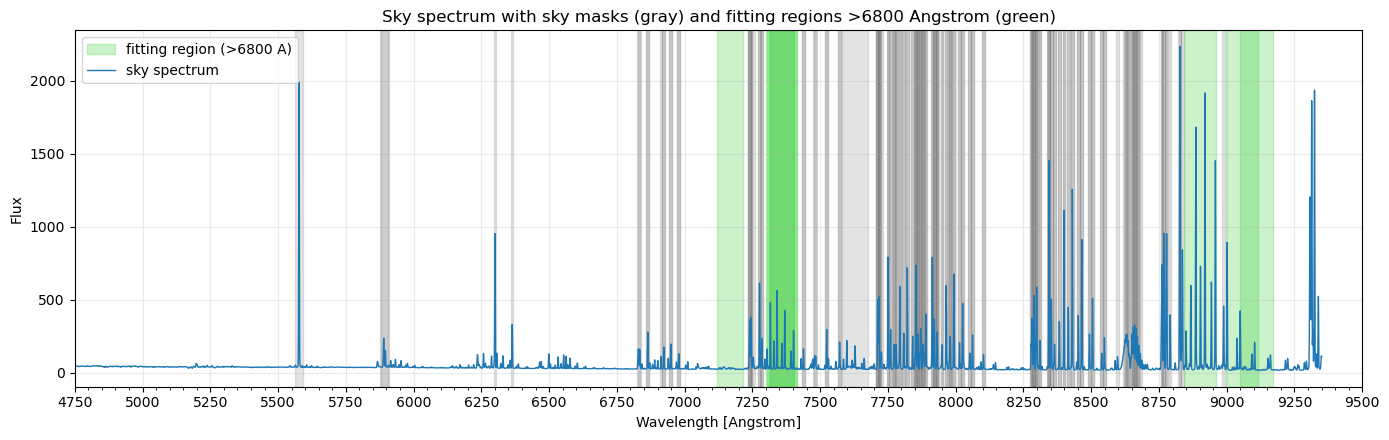

FITS file: /Users/Igniz/Desktop/ICRAR/nGIST_dev_7.6.4/SKY_SPECTRUM_2023-01-18T07_13_15_0001.fits
Mask file: /Users/Igniz/Desktop/ICRAR/nGIST_dev_7.6.4/specMask_GAS_narrow10
Sky-mask spans shown: 181
Fitting regions shown (Lambda > 6800 Angstrom): 8


In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from astropy.io import fits

fits_path = Path.cwd() / 'SKY_SPECTRUM_2023-01-18T07_13_15_0001.fits'
mask_path = Path.cwd() / 'specMask_GAS_narrow10'

fit_lines = [7135.79, 7318.92, 7319.99, 7329.67, 7330.73, 8862.89, 9015.30, 9068.60]
fit_min_lambda = 6800.0
z_min, z_max = -0.001, 0.01
fit_width = 20.0
fit_half = fit_width / 2.0


def load_sky_masks(path):
    masks = []
    for raw in path.read_text().splitlines():
        line = raw.strip()
        if not line or line.startswith('#'):
            continue
        parts = raw.split()
        if len(parts) < 3:
            continue
        try:
            lam = float(parts[0])
            width = float(parts[1])
        except ValueError:
            continue
        if parts[2].strip().lower() == 'sky':
            half = width / 2.0
            masks.append((lam - half, lam + half, lam, width))
    return masks


def load_spectrum(path):
    with fits.open(path) as hdul:
        data_hdu_idx = None
        for i, hdu in enumerate(hdul):
            if getattr(hdu, 'data', None) is not None:
                data_hdu_idx = i
                break
        if data_hdu_idx is None:
            raise ValueError('No data HDU found in FITS file.')

        data = hdul[data_hdu_idx].data

    if hasattr(data, 'names') and data.names is not None:
        wave_col = None
        flux_col = None
        for name in data.names:
            low = name.lower()
            if wave_col is None and low in ('lambda', 'wave', 'wavelength', 'lam'):
                wave_col = name
            if flux_col is None and low in ('data', 'flux', 'spec', 'spectrum'):
                flux_col = name
        if wave_col is None:
            wave_col = data.names[0]
        if flux_col is None:
            flux_col = data.names[1] if len(data.names) >= 2 else data.names[0]

        wave = np.asarray(data[wave_col], dtype=float)
        flux = np.asarray(data[flux_col], dtype=float)
    else:
        arr = np.asarray(data, dtype=float)
        if arr.ndim != 1:
            raise ValueError('Expected 1D spectrum or table with wavelength/flux columns.')
        wave = np.arange(arr.size, dtype=float)
        flux = arr

    finite = np.isfinite(wave) & np.isfinite(flux)
    return wave[finite], flux[finite]


def add_sky_spans(ax, masks, wave):
    wmin, wmax = np.nanmin(wave), np.nanmax(wave)
    n = 0
    for left, right, _, _ in masks:
        if right < wmin or left > wmax:
            continue
        ax.axvspan(left, right, color='gray', alpha=0.22, zorder=0)
        n += 1
    return n


def add_fit_spans(ax, lines, min_lambda, z0, z1, half_width):
    spans = []
    for lam0 in lines:
        if lam0 <= min_lambda:
            continue
        left = lam0 * (1.0 + z0) - half_width
        right = lam0 * (1.0 + z1) + half_width
        spans.append((left, right, lam0))
    for i, (left, right, _) in enumerate(spans):
        ax.axvspan(left, right, color='limegreen', alpha=0.25, zorder=1,
                   label='fitting region (>6800 A)' if i == 0 else None)
    return spans


def configure_ticks(ax, wmin, wmax):
    span = wmax - wmin
    if span <= 800:
        major, minor = 50.0, 10.0
    elif span <= 2000:
        major, minor = 100.0, 20.0
    else:
        major, minor = 250.0, 50.0
    first = np.floor(wmin / major) * major
    last = np.ceil(wmax / major) * major
    ax.set_xticks(np.arange(first, last + major, major))
    ax.xaxis.set_minor_locator(MultipleLocator(minor))


if not fits_path.exists():
    raise FileNotFoundError(f'FITS file not found: {fits_path}')
if not mask_path.exists():
    raise FileNotFoundError(f'Mask file not found: {mask_path}')

sky_masks = load_sky_masks(mask_path)
wave, flux = load_spectrum(fits_path)

fig, ax = plt.subplots(figsize=(14, 4.5))
shown_sky = add_sky_spans(ax, sky_masks, wave)
fit_spans = add_fit_spans(ax, fit_lines, fit_min_lambda, z_min, z_max, fit_half)

ax.plot(wave, flux, lw=1.0, color='tab:blue', label='sky spectrum', zorder=2)
ax.set_xlim(np.nanmin(wave), np.nanmax(wave))
ax.set_xlabel('Wavelength [Angstrom]')
ax.set_ylabel('Flux')
ax.set_title('Sky spectrum with sky masks (gray) and fitting regions >6800 Angstrom (green)')
configure_ticks(ax, np.nanmin(wave), np.nanmax(wave))
ax.grid(alpha=0.25)
ax.legend(loc='upper left')
fig.tight_layout()
plt.show()

print(f'FITS file: {fits_path}')
print(f'Mask file: {mask_path}')
print(f'Sky-mask spans shown: {shown_sky}')
print(f'Fitting regions shown (Lambda > {fit_min_lambda:.0f} Angstrom): {len(fit_spans)}')